#### LightGBM Model

Two LightGBM models for hourly onset prediction, directly comparable to the logistic regression baseline:
- LGB M1: 18 weather features (same feature set as LR M1)
- LGB M2: 19 features — weather + `n_onsets_last_90d` (same as LR M2)


#### 1. Setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, precision_recall_curve
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import shap
import pickle
print(f'LightGBM {lgb.__version__}  |  SHAP {shap.__version__}')

FEATURES_PATH = '../data/features_v2.parquet'
FIGURES_PATH  = '../figures/'
MODELS_PATH   = '../models/'

TRAIN_YEARS  = list(range(2015, 2022))
VAL_YEARS    = [2022]
TEST_YEARS   = [2023, 2024]
RANDOM_STATE = 42
TARGET       = 'is_onset'

WEATHER_FEATURES = [
    'rolling_temp_max_24h', 'relative_humidity_2m', 'precipitation',
    'snowfall', 'wind_speed_10m', 'surface_pressure', 'shortwave_radiation',
    'cloud_cover', 'local_temp_pct_bin', 'temp_x_humidity',
    'cold_stress_index', 'fuel_gas_x_temp', 'capacity_size',
    'load_mwh', 'rolling_load_24h', 'year',
    'fuel_Fossil Gas', 'fuel_Fossil Brown coal/Lignite',
]
assert len(WEATHER_FEATURES) == 18

FULL_FEATURES = WEATHER_FEATURES + ['n_onsets_last_90d']
assert len(FULL_FEATURES) == 19

FEATURE_GROUPS = {
    'Weather raw':         ['rolling_temp_max_24h', 'relative_humidity_2m',
                            'precipitation', 'snowfall', 'wind_speed_10m',
                            'surface_pressure', 'shortwave_radiation', 'cloud_cover'],
    'Weather engineered':  ['local_temp_pct_bin'],
    'Compound weather':    ['temp_x_humidity', 'cold_stress_index', 'fuel_gas_x_temp'],
    'Capacity':            ['capacity_size'],
    'Load':                ['load_mwh', 'rolling_load_24h'],
    'Structural':          ['year'],
    'Fuel':                ['fuel_Fossil Gas', 'fuel_Fossil Brown coal/Lignite'],
    'Operational history': ['n_onsets_last_90d'],
}
GROUP_COLORS = {
    'Weather raw':          '#4C72B0',
    'Weather engineered':   '#1a3a6b',
    'Compound weather':     '#7ea8d4',
    'Capacity':             '#8c8c8c',
    'Load':                 '#55A868',
    'Structural':           '#c8c8c8',
    'Fuel':                 '#DD8452',
    'Operational history':  '#C44E52',
}
FEAT_GROUP = {f: g for g, feats in FEATURE_GROUPS.items() for f in feats}
print(f'LGB M1: {len(WEATHER_FEATURES)} features | LGB M2: {len(FULL_FEATURES)} features')

LightGBM 4.6.0  |  SHAP 0.51.0
LGB M1: 18 features | LGB M2: 19 features


#### 2. Load Data and Split

In [2]:

df = pd.read_parquet(FEATURES_PATH)
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values(['EICCode', 'DateTime']).reset_index(drop=True)
print(f'  Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

train = df[df['year'].isin(TRAIN_YEARS)].copy()
val   = df[df['year'].isin(VAL_YEARS)].copy()
test  = df[df['year'].isin(TEST_YEARS)].copy()

print(f'\n{"Split":<20} {"Rows":>12} {"Onsets":>8} {"Rate":>10}')
print('-' * 54)
for name, s in [('Train 2015-2021', train), ('Val 2022', val), ('Test 2023-2024', test)]:
    n = len(s); k = s[TARGET].sum()
    print(f'{name:<20} {n:>12,} {k:>8,} {k/n*100:>9.4f}%')

# Impute missing values (train-fitted, no scaling for LGB)
imputer_lgb = SimpleImputer(strategy='median')
X_tr_raw = train[FULL_FEATURES].astype(float).values
X_va_raw = val[FULL_FEATURES].astype(float).values
X_te_raw = test[FULL_FEATURES].astype(float).values

X_tr_imp = imputer_lgb.fit_transform(X_tr_raw)
X_va_imp = imputer_lgb.transform(X_va_raw)
X_te_imp = imputer_lgb.transform(X_te_raw)

W = len(WEATHER_FEATURES)
X_tr_w, X_va_w, X_te_w = X_tr_imp[:, :W], X_va_imp[:, :W], X_te_imp[:, :W]
X_tr_f, X_va_f, X_te_f = X_tr_imp,        X_va_imp,        X_te_imp

y_train = train[TARGET].values.astype(int)
y_val   = val[TARGET].values.astype(int)
y_test  = test[TARGET].values.astype(int)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f'\nscale_pos_weight = {n_neg:,} / {n_pos:,} = {scale_pos_weight:.1f}')

with open(MODELS_PATH + 'lgb_imputer.pkl', 'wb') as f: pickle.dump(imputer_lgb, f)

  Loaded: 11,935,399 rows x 29 columns

Split                        Rows   Onsets       Rate
------------------------------------------------------
Train 2015-2021         8,698,327    7,113    0.0818%
Val 2022                1,127,257      952    0.0845%
Test 2023-2024          2,109,815    1,767    0.0838%

scale_pos_weight = 8,691,214 / 7,113 = 1221.9


#### 3. Hyperparameter Tuning (Validation Set)

In [3]:
from itertools import product as iproduct

param_grid = {
    'learning_rate':      [0.05, 0.01],
    'num_leaves':         [31, 63],
    'min_child_samples':  [100, 500],
}
fixed_params = dict(
    objective='binary', metric='auc',
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    n_estimators=500,
    random_state=RANDOM_STATE,
    verbose=-1, n_jobs=4,
)

callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]

best_auc, best_params, best_iter = -1, {}, 0
print(f'{"lr":>6} {"leaves":>7} {"mcs":>6}  {"val_auc":>9}  {"iters":>6}')
print('-' * 44)

for lr, nl, mcs in iproduct(param_grid['learning_rate'],
                              param_grid['num_leaves'],
                              param_grid['min_child_samples']):
    m = lgb.LGBMClassifier(
        learning_rate=lr, num_leaves=nl, min_child_samples=mcs,
        **fixed_params
    )
    m.fit(X_tr_w, y_train, eval_set=[(X_va_w, y_val)], callbacks=callbacks)
    va_auc = roc_auc_score(y_val, m.predict_proba(X_va_w)[:, 1])
    n_iter = m.best_iteration_ if m.best_iteration_ else m.n_estimators_
    print(f'{lr:>6} {nl:>7} {mcs:>6}  {va_auc:>9.4f}  {n_iter:>6}')
    if va_auc > best_auc:
        best_auc  = va_auc
        best_iter = n_iter
        best_params = {'learning_rate': lr, 'num_leaves': nl, 'min_child_samples': mcs}

print(f'\nBest params: {best_params}')
print(f'Best val AUC: {best_auc:.4f}  (best_iteration={best_iter})')

    lr  leaves    mcs    val_auc   iters
--------------------------------------------
  0.05      31    100     0.6308       1
  0.05      31    500     0.6308       1
  0.05      63    100     0.5973       9
  0.05      63    500     0.5781      14
  0.01      31    100     0.6374       5
  0.01      31    500     0.6378       2
  0.01      63    100     0.5754       1
  0.01      63    500     0.5754       1

Best params: {'learning_rate': 0.01, 'num_leaves': 31, 'min_child_samples': 500}
Best val AUC: 0.6378  (best_iteration=2)


#### 4. LGB Model 1 — Weather Only (18 features)

In [10]:
lgb_params = dict(
    objective='binary', metric='auc',
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    n_estimators=1000,
    random_state=RANDOM_STATE,
    verbose=-1, n_jobs=4,
    **best_params,
)
callbacks_fit = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]


lgb_model1 = lgb.LGBMClassifier(**lgb_params)
lgb_model1.fit(X_tr_w, y_train, eval_set=[(X_va_w, y_val)], callbacks=callbacks_fit)

best_it1 = lgb_model1.best_iteration_
va_auc1  = roc_auc_score(y_val,  lgb_model1.predict_proba(X_va_w)[:, 1])
te_auc1  = roc_auc_score(y_test, lgb_model1.predict_proba(X_te_w)[:, 1])
print(f'  Best iteration : {best_it1}')
print(f'  Val  AUC-ROC   : {va_auc1:.4f}')
print(f'  Test AUC-ROC   : {te_auc1:.4f}')

with open(MODELS_PATH + 'lgb_model1_final.pkl', 'wb') as f: pickle.dump(lgb_model1, f)



  Best iteration : 2
  Val  AUC-ROC   : 0.6378
  Test AUC-ROC   : 0.6226


#### 4b. LGB Model 1 - Learning Curves

Trained 500 iterations  |  training: 0.7460  |  valid_1: 0.6161
Best val AUC at iter 2: 0.6378

  Iter   Train AUC     Val AUC
------------------------------
     1      0.6747      0.6308
    51      0.6896      0.6189
   101      0.6958      0.6142
   151      0.7026      0.6128
   201      0.7106      0.6115
   251      0.7180      0.6120
   301      0.7246      0.6134
   351      0.7307      0.6143
   401      0.7362      0.6152
   451      0.7413      0.6161
   500      0.7460      0.6161


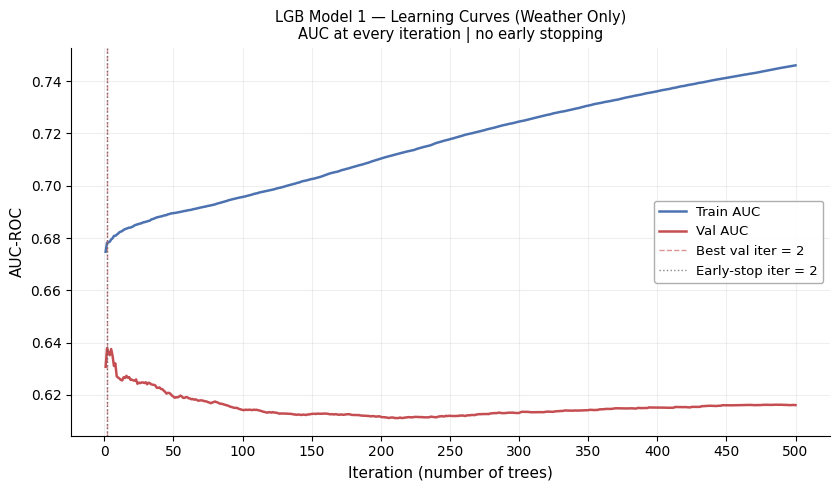

Saved: lgb_learning_curves.png


In [8]:
# Retrain LGB M1 with full 500 iter (no early stopping) to capture learning curves
lgb_params_lc = {k: v for k, v in lgb_params.items()}
lgb_params_lc['n_estimators'] = 500

evals_lc = {}
lgb_m1_lc = lgb.LGBMClassifier(**lgb_params_lc)
lgb_m1_lc.fit(
    X_tr_w, y_train,
    eval_set=[(X_tr_w, y_train), (X_va_w, y_val)],
    callbacks=[lgb.record_evaluation(evals_lc), lgb.log_evaluation(-1)],
)
# Key names: first eval_set entry = 'training', second = 'valid_0'
tr_key  = list(evals_lc.keys())[0]
va_key  = list(evals_lc.keys())[1]
tr_auc  = evals_lc[tr_key]['auc']
va_auc  = evals_lc[va_key]['auc']
n_iter  = len(tr_auc)

every   = 50
iters   = list(range(0, n_iter, every)) + ([n_iter - 1] if (n_iter - 1) % every != 0 else [])
tr_plot = [tr_auc[i] for i in iters]
va_plot = [va_auc[i] for i in iters]
x_plot  = [i + 1 for i in iters]

print(f'Trained {n_iter} iterations  |  {tr_key}: {tr_auc[-1]:.4f}  |  {va_key}: {va_auc[-1]:.4f}')
print(f'Best val AUC at iter {va_auc.index(max(va_auc)) + 1}: {max(va_auc):.4f}')
print(f'\n{"Iter":>6}  {"Train AUC":>10}  {"Val AUC":>10}')
print('-' * 30)
for it, tr, va in zip(x_plot, tr_plot, va_plot):
    print(f'{it:>6}  {tr:>10.4f}  {va:>10.4f}')

best_val_iter = va_auc.index(max(va_auc)) + 1

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(range(1, n_iter + 1), tr_auc, color='#4C72B0', lw=1.8, label='Train AUC')
ax.plot(range(1, n_iter + 1), va_auc, color='#C44E52', lw=1.8, label='Val AUC')
ax.axvline(best_val_iter, color='#C44E52', ls='--', lw=1.0, alpha=0.6,
           label=f'Best val iter = {best_val_iter}')
ax.axvline(lgb_model1.best_iteration_, color='#555555', ls=':', lw=1.0, alpha=0.7,
           label=f'Early-stop iter = {lgb_model1.best_iteration_}')
ax.set_xlabel('Iteration (number of trees)', fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('LGB Model 1 — Learning Curves (Weather Only)\n'
             'AUC at every iteration | no early stopping', fontsize=10.5)
ax.legend(fontsize=9.5, framealpha=0.95, edgecolor='#aaaaaa')
ax.set_xticks(range(0, n_iter + 1, every))
ax.grid(alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES_PATH + 'lgb_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: lgb_learning_curves.png')


#### 5. LGB Model 2 - Weather + History (19 features)

In [9]:

lgb_model2 = lgb.LGBMClassifier(**lgb_params)
lgb_model2.fit(X_tr_f, y_train, eval_set=[(X_va_f, y_val)], callbacks=callbacks_fit)

best_it2 = lgb_model2.best_iteration_
va_auc2  = roc_auc_score(y_val,  lgb_model2.predict_proba(X_va_f)[:, 1])
te_auc2  = roc_auc_score(y_test, lgb_model2.predict_proba(X_te_f)[:, 1])
print(f'  Best iteration : {best_it2}')
print(f'  Val  AUC-ROC   : {va_auc2:.4f}')
print(f'  Test AUC-ROC   : {te_auc2:.4f}')

with open(MODELS_PATH + 'lgb_model2_final.pkl', 'wb') as f: pickle.dump(lgb_model2, f)


  Best iteration : 7
  Val  AUC-ROC   : 0.7978
  Test AUC-ROC   : 0.7572


#### 6. Evaluation and 4-Model Comparison

In [23]:
def evaluate(proba, y):
    return {
        'auc':   roc_auc_score(y, proba),
        'ap':    average_precision_score(y, proba),
        'brier': brier_score_loss(y, proba),
        'proba': proba,
    }

# LGB raw probabilities
r_lgb = {
    'm1_tr': evaluate(lgb_model1.predict_proba(X_tr_w)[:, 1], y_train),
    'm1_va': evaluate(lgb_model1.predict_proba(X_va_w)[:, 1], y_val),
    'm1_te': evaluate(lgb_model1.predict_proba(X_te_w)[:, 1], y_test),
    'm2_tr': evaluate(lgb_model2.predict_proba(X_tr_f)[:, 1], y_train),
    'm2_va': evaluate(lgb_model2.predict_proba(X_va_f)[:, 1], y_val),
    'm2_te': evaluate(lgb_model2.predict_proba(X_te_f)[:, 1], y_test),
}

# Platt scaling for LGB (val set, log-odds input)
def platt_scale_lgb(model, X_val, y_val, X_test):
    eps = 1e-7
    p_val  = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]
    lo_val  = np.log(p_val  / (1 - p_val  + eps)).reshape(-1, 1)
    lo_test = np.log(p_test / (1 - p_test + eps)).reshape(-1, 1)
    platt = LogisticRegression(max_iter=1000)
    platt.fit(lo_val, y_val)
    return platt.predict_proba(lo_test)[:, 1], platt

cal_proba_lgb1, platt_lgb1 = platt_scale_lgb(lgb_model1, X_va_w, y_val, X_te_w)
cal_proba_lgb2, platt_lgb2 = platt_scale_lgb(lgb_model2, X_va_f, y_val, X_te_f)

with open(MODELS_PATH + 'lgb_platt1.pkl', 'wb') as f: pickle.dump(platt_lgb1, f)
with open(MODELS_PATH + 'lgb_platt2.pkl', 'wb') as f: pickle.dump(platt_lgb2, f)

rc_lgb = {
    'm1_te': evaluate(cal_proba_lgb1, y_test),
    'm2_te': evaluate(cal_proba_lgb2, y_test),
}

# Load LR models
with open(MODELS_PATH + 'imputer_final.pkl', 'rb') as f: lr_imputer = pickle.load(f)
with open(MODELS_PATH + 'scaler_final.pkl',  'rb') as f: lr_scaler  = pickle.load(f)
with open(MODELS_PATH + 'model1_final.pkl',  'rb') as f: lr_model1  = pickle.load(f)
with open(MODELS_PATH + 'model2_final.pkl',  'rb') as f: lr_model2  = pickle.load(f)
with open(MODELS_PATH + 'platt1_final.pkl',  'rb') as f: lr_platt1  = pickle.load(f)
with open(MODELS_PATH + 'platt2_final.pkl',  'rb') as f: lr_platt2  = pickle.load(f)

W_lr = len(WEATHER_FEATURES)   # 18

def lr_eval(lr_model, lr_platt, split_df, y, weather_only=True):
    # LR imputer/scaler was fitted on 19 FULL_FEATURES
    X_raw = split_df[FULL_FEATURES].astype(float).values
    X_imp = lr_imputer.transform(X_raw)
    X_sc  = lr_scaler.transform(X_imp)
    X_in  = X_sc[:, :W_lr] if weather_only else X_sc
    df    = lr_model.decision_function(X_in).reshape(-1, 1)
    proba = lr_platt.predict_proba(df)[:, 1]
    return evaluate(proba, y)

rc_lr = {
    'm1_va': lr_eval(lr_model1, lr_platt1, val,  y_val,  weather_only=True),
    'm1_te': lr_eval(lr_model1, lr_platt1, test, y_test, weather_only=True),
    'm2_va': lr_eval(lr_model2, lr_platt2, val,  y_val,  weather_only=False),
    'm2_te': lr_eval(lr_model2, lr_platt2, test, y_test, weather_only=False),
}

# LR uncalibrated AUC for final summary
def lr_uncal_auc(lr_model, split_df, y, weather_only=True):
    X_raw = split_df[FULL_FEATURES].astype(float).values
    X_imp = lr_imputer.transform(X_raw)
    X_sc  = lr_scaler.transform(X_imp)
    X_in  = X_sc[:, :W_lr] if weather_only else X_sc
    return roc_auc_score(y, lr_model.predict_proba(X_in)[:, 1])

lr_m1_tr_auc = lr_uncal_auc(lr_model1, train, y_train, weather_only=True)
lr_m2_tr_auc = lr_uncal_auc(lr_model2, train, y_train, weather_only=False)

print('4-MODEL COMPARISON (calibrated test-set metrics)')

print(f'{"Model":<28} {"Val AUC":>9} {"Val AP":>9} {"Test AUC":>9} {"Test AP":>9} {"Brier":>9}')

rows = [
    ('LR  M1 (Weather only)',   rc_lr['m1_va'],  rc_lr['m1_te']),
    ('LR  M2 (Weather + Hist)', rc_lr['m2_va'],  rc_lr['m2_te']),
    ('LGB M1 (Weather only)',   r_lgb['m1_va'],  rc_lgb['m1_te']),
    ('LGB M2 (Weather + Hist)', r_lgb['m2_va'],  rc_lgb['m2_te']),
]
for label, va, te in rows:
    print(f'{label:<28} {va["auc"]:>9.4f} {va["ap"]:>9.4f} {te["auc"]:>9.4f} {te["ap"]:>9.4f} {te["brier"]:>9.6f}')
print()
d_lgb_weather = r_lgb['m1_te']['auc'] - rc_lr['m1_te']['auc']
d_lgb_hist    = r_lgb['m2_te']['auc'] - r_lgb['m1_te']['auc']
d_lr_hist     = rc_lr['m2_te']['auc'] - rc_lr['m1_te']['auc']
print(f'AUC gain: LGB vs LR (weather only)  = {d_lgb_weather:+.4f}')
print(f'AUC gain: adding history (LGB)      = {d_lgb_hist:+.4f}')
print(f'AUC gain: adding history (LR)       = {d_lr_hist:+.4f}')

4-MODEL COMPARISON (calibrated test-set metrics)
Model                          Val AUC    Val AP  Test AUC   Test AP     Brier
LR  M1 (Weather only)           0.6728    0.0015    0.6624    0.0015  0.000837
LR  M2 (Weather + Hist)         0.7962    0.0053    0.7603    0.0027  0.000836
LGB M1 (Weather only)           0.6378    0.0013    0.6226    0.0013  0.000837
LGB M2 (Weather + Hist)         0.7978    0.0039    0.7572    0.0024  0.000836

AUC gain: LGB vs LR (weather only)  = -0.0398
AUC gain: adding history (LGB)      = +0.1346
AUC gain: adding history (LR)       = +0.0979


#### 7. SHAP Feature Importance — LGB Model 1

SHAP sample: 3,534 rows  (1767 onsets, 1767 non-onsets)
Computing SHAP values (TreeExplainer) ...
SHAP values shape: (3534, 18)


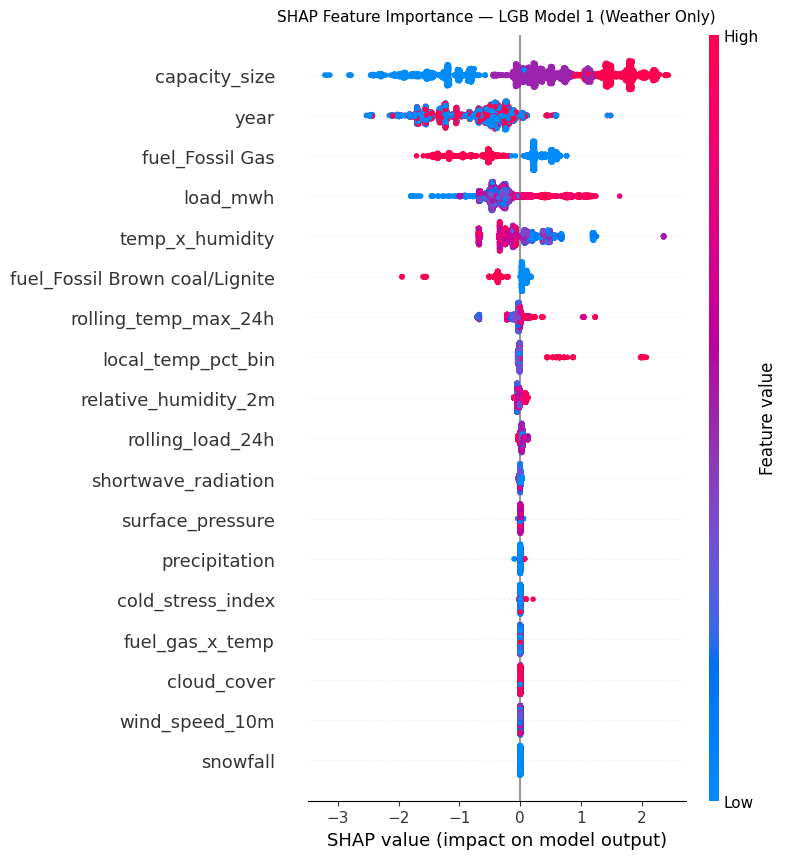

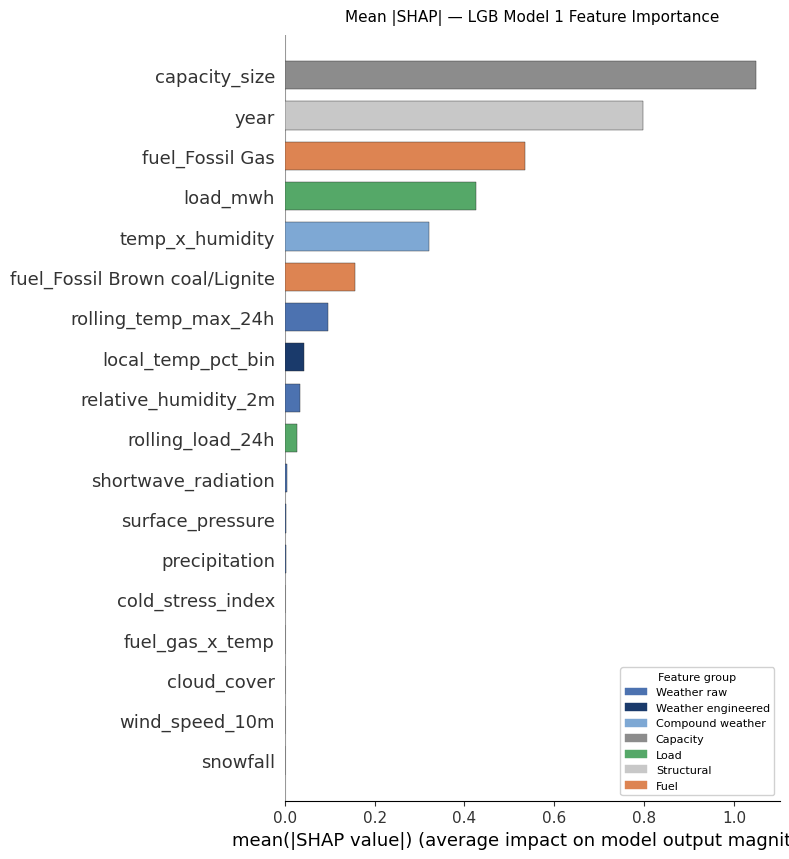

In [14]:
rng_shap = np.random.default_rng(RANDOM_STATE)
pos_idx  = np.where(y_test == 1)[0]
neg_idx  = np.where(y_test == 0)[0]
n_shap   = min(5000, len(pos_idx))
neg_shap = rng_shap.choice(neg_idx, size=min(n_shap, len(neg_idx)), replace=False)
shap_idx = np.concatenate([pos_idx[:n_shap], neg_shap])
rng_shap.shuffle(shap_idx)
shap_idx = shap_idx[:10_000]

X_shap = X_te_w[shap_idx]
X_shap_df = pd.DataFrame(X_shap, columns=WEATHER_FEATURES)
print(f'SHAP sample: {len(shap_idx):,} rows  '
      f'({(y_test[shap_idx]==1).sum()} onsets, '
      f'{(y_test[shap_idx]==0).sum()} non-onsets)')

print('Computing SHAP values (TreeExplainer) ...')
shap_explainer = shap.TreeExplainer(lgb_model1)
sv = shap_explainer.shap_values(X_shap)
# Handle both old list format and new array format
if isinstance(sv, list):
    shap_vals = sv[1]
elif hasattr(sv, 'ndim') and sv.ndim == 3:
    shap_vals = sv[:, :, 1]
else:
    shap_vals = sv
print(f'SHAP values shape: {shap_vals.shape}')

# Plot 1: Beeswarm summary
fig1, ax1 = plt.subplots(figsize=(9, 7))
plt.sca(ax1)
shap.summary_plot(shap_vals, X_shap_df, feature_names=WEATHER_FEATURES,
                  max_display=18, show=False)
plt.title('SHAP Feature Importance — LGB Model 1 (Weather Only)', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'lgb_shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()


# Plot 2: Bar — mean |SHAP|, colored by feature group
shap.summary_plot(shap_vals, X_shap_df, feature_names=WEATHER_FEATURES,
                  plot_type='bar', max_display=18, show=False)
ax_bar = plt.gca()
# Recolor bars by feature group
ytick_labels = [t.get_text() for t in ax_bar.get_yticklabels()]
patches = ax_bar.patches
for patch, fname in zip(patches, ytick_labels):
    grp = FEAT_GROUP.get(fname, 'Weather raw')
    patch.set_facecolor(GROUP_COLORS[grp])
    patch.set_edgecolor('#2a2a2a')
    patch.set_linewidth(0.3)
# Legend
legend_items = [mpatches.Patch(color=GROUP_COLORS[g], label=g, linewidth=0.3,
                                edgecolor='#333') for g in FEATURE_GROUPS if g != 'Operational history']
ax_bar.legend(handles=legend_items, fontsize=8, loc='lower right',
              framealpha=0.9, title='Feature group', title_fontsize=8)
plt.title('Mean |SHAP| — LGB Model 1 Feature Importance', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'lgb_shap_bar.png', dpi=200, bbox_inches='tight')
plt.show()


#### 8. SHAP Dependence Plots

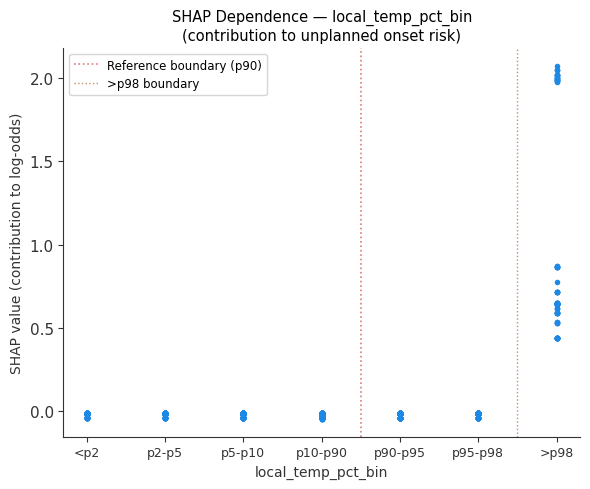

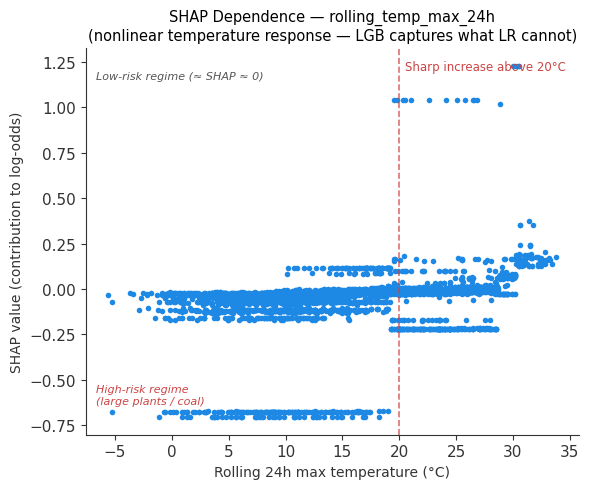

In [15]:
bin_col_idx = WEATHER_FEATURES.index('local_temp_pct_bin')
xlabels_bin = ['<p2', 'p2-p5', 'p5-p10', 'p10-p90', 'p90-p95', 'p95-p98', '>p98']

# Plot 3: local_temp_pct_bin dependence
shap.dependence_plot(
    'local_temp_pct_bin', shap_vals, X_shap_df,
    feature_names=WEATHER_FEATURES,
    interaction_index=None, show=False,
)
ax3 = plt.gca()
ax3.axvline(3.5, color='#cc4444', ls=':', lw=1.2, alpha=0.7, label='Reference boundary (p90)')
ax3.axvline(5.5, color='#994400', ls=':', lw=1.0, alpha=0.6, label='>p98 boundary')
ax3.set_xticks(range(7))
ax3.set_xticklabels(xlabels_bin, fontsize=9)
ax3.set_xlabel('local_temp_pct_bin', fontsize=10)
ax3.set_ylabel('SHAP value (contribution to log-odds)', fontsize=10)
ax3.set_title('SHAP Dependence — local_temp_pct_bin\n'
              '(contribution to unplanned onset risk)', fontsize=10.5)
ax3.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'lgb_shap_tempbin.png', dpi=200, bbox_inches='tight')
plt.show()


# Plot 4: rolling_temp_max_24h dependence
shap.dependence_plot(
    'rolling_temp_max_24h', shap_vals, X_shap_df,
    feature_names=WEATHER_FEATURES,
    interaction_index=None, show=False,
)
ax4 = plt.gca()
ax4.set_xlabel('Rolling 24h max temperature (°C)', fontsize=10)
ax4.set_ylabel('SHAP value (contribution to log-odds)', fontsize=10)
ax4.set_title('SHAP Dependence — rolling_temp_max_24h\n'
              '(nonlinear temperature response — LGB captures what LR cannot)', fontsize=10.5)
ax4.axvline(20, color='#cc4444', ls='--', lw=1.2, alpha=0.75)
ax4.text(20.5, 0.97, 'Sharp increase above 20°C',
         transform=ax4.get_xaxis_transform(), fontsize=8.5, color='#cc4444',
         va='top')
# Band labels using axes-fraction y (estimated from SHAP value distribution)
ax4.text(0.02, 0.92, 'Low-risk regime (≈ SHAP ≈ 0)',
         transform=ax4.transAxes, fontsize=8, color='#555555', style='italic')
ax4.text(0.02, 0.08, 'High-risk regime\n(large plants / coal)',
         transform=ax4.transAxes, fontsize=8, color='#cc4444', style='italic')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'lgb_shap_rollingtemp.png', dpi=200, bbox_inches='tight')
plt.show()


#### 9. Fuel-Specific SHAP Analysis

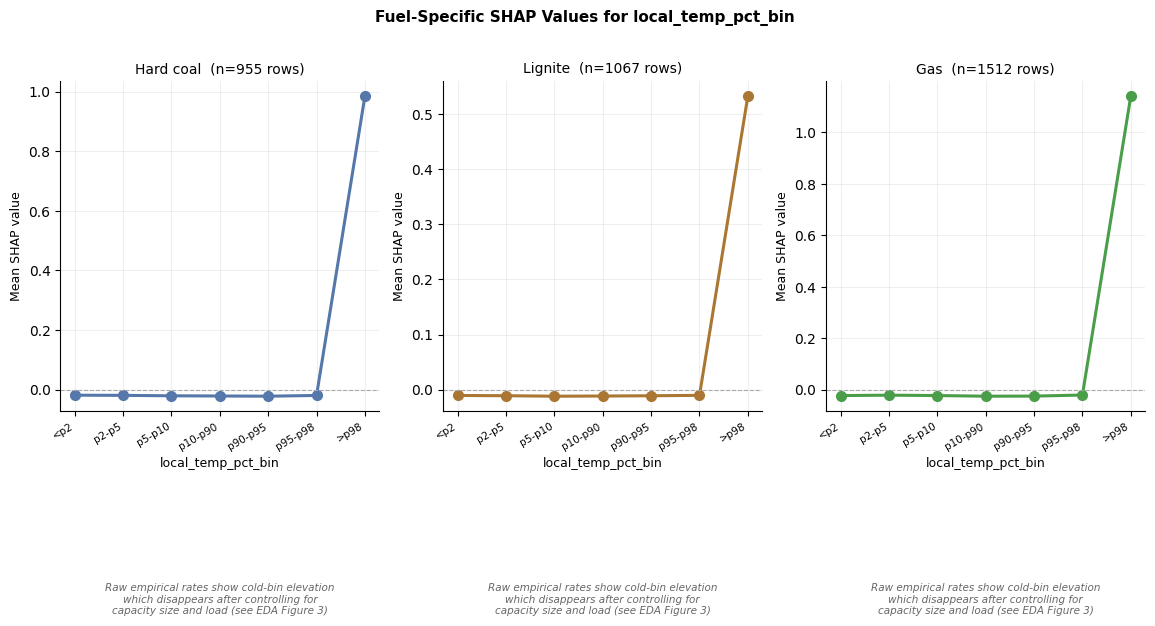

In [16]:
# Fuel labels for shap sample rows
gas_col     = WEATHER_FEATURES.index('fuel_Fossil Gas')
lignite_col = WEATHER_FEATURES.index('fuel_Fossil Brown coal/Lignite')
fuel_label  = np.where(X_shap[:, gas_col] > 0.5, 'Gas',
              np.where(X_shap[:, lignite_col] > 0.5, 'Lignite', 'Hard coal'))

bin_shap_idx = WEATHER_FEATURES.index('local_temp_pct_bin')
bins = list(range(7))
FUEL_COLORS = {'Hard coal': '#5577aa', 'Lignite': '#aa7733', 'Gas': '#4a9e4a'}

NOTE = ('Raw empirical rates show cold-bin elevation\n'
        'which disappears after controlling for\n'
        'capacity size and load (see EDA Figure 3)')

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))
plt.subplots_adjust(bottom=0.28)

for ax, fuel in zip(axes, ['Hard coal', 'Lignite', 'Gas']):
    mask   = fuel_label == fuel
    sv_f   = shap_vals[mask, bin_shap_idx]
    bins_f = X_shap[mask, bin_shap_idx].astype(int)
    mean_shap = [sv_f[bins_f == b].mean() if (bins_f == b).sum() > 0 else np.nan
                 for b in bins]
    ax.plot(bins, mean_shap, 'o-', color=FUEL_COLORS[fuel], lw=2.2, ms=7)
    ax.axhline(0, color='#aaaaaa', lw=0.8, ls='--')
    ax.set_xticks(bins)
    ax.set_xticklabels(['<p2','p2-p5','p5-p10','p10-p90','p90-p95','p95-p98','>p98'],
                        fontsize=7.5, rotation=30, ha='right')
    ax.set_xlabel('local_temp_pct_bin', fontsize=9)
    ax.set_ylabel('Mean SHAP value', fontsize=9)
    ax.set_title(f'{fuel}  (n={mask.sum()} rows)', fontsize=10)
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.text(0.5, -0.52, NOTE, transform=ax.transAxes,
            ha='center', va='top', fontsize=7.5, color='#666666', style='italic')

fig.suptitle('Fuel-Specific SHAP Values for local_temp_pct_bin',
             fontsize=11, y=1.01, fontweight='semibold')
fig.savefig(FIGURES_PATH + 'lgb_shap_fuel_specific.png', dpi=200, bbox_inches='tight')
plt.show()


#### 10. LR vs LGB Feature Importance Comparison

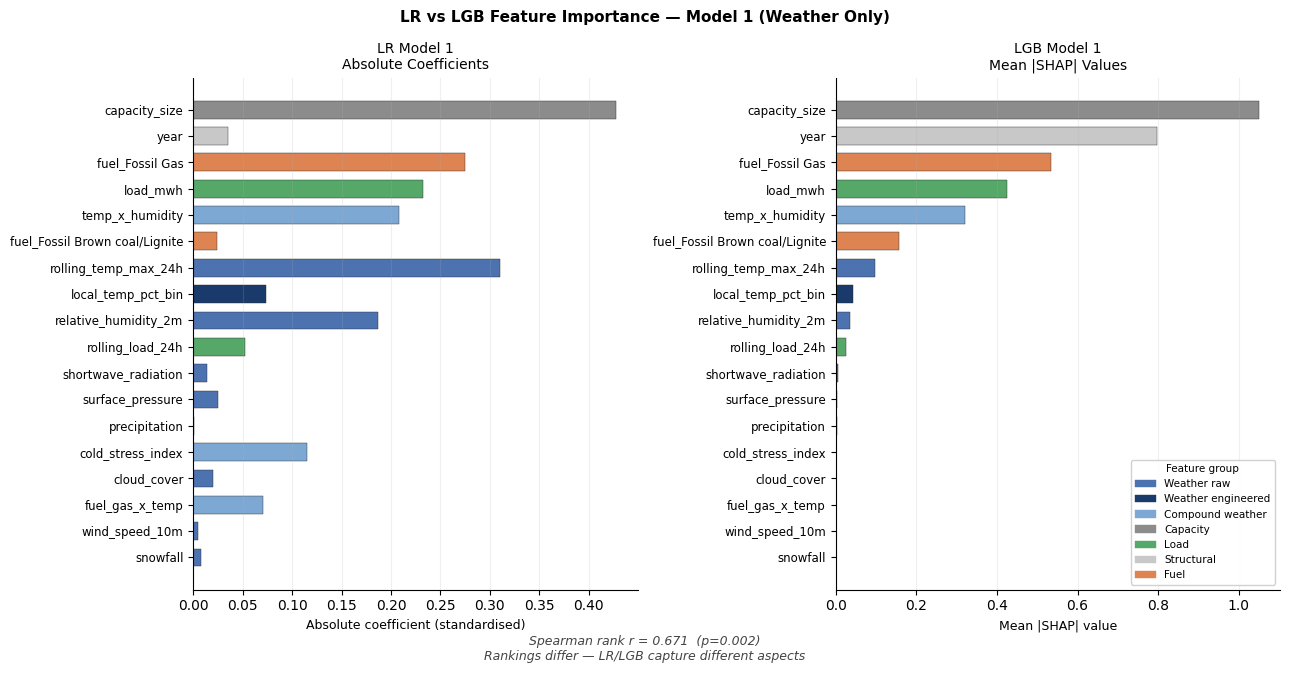

In [17]:
# LGB mean |SHAP|
lgb_importance = pd.Series(np.abs(shap_vals).mean(axis=0), index=WEATHER_FEATURES)
lgb_importance = lgb_importance.sort_values(ascending=False)

# LR absolute coefficients — reload from saved statsmodels run
# We use LR model1 coefficients (sklearn) as proxy for |coef| ranking
lr_coefs = pd.Series(np.abs(lr_model1.coef_[0]), index=WEATHER_FEATURES)

# Align both to LGB ordering
feat_order = lgb_importance.index.tolist()
lgb_vals   = lgb_importance[feat_order].values
lr_vals    = lr_coefs[feat_order].values

# Spearman rank correlation
lr_rank  = lr_coefs.rank(ascending=False)
lgb_rank = lgb_importance.rank(ascending=False)
rho, pval = spearmanr(lr_rank[feat_order], lgb_rank[feat_order])
agree = 'Rankings consistent across models' if rho >= 0.7 else 'Rankings differ — LR/LGB capture different aspects'

colors_bar = [GROUP_COLORS[FEAT_GROUP[f]] for f in feat_order]

fig, (ax_lr, ax_lgb) = plt.subplots(1, 2, figsize=(13, 6.5))
y_pos = np.arange(len(feat_order))

ax_lr.barh(y_pos, lr_vals[::-1], color=colors_bar[::-1],
           edgecolor='#2a2a2a', linewidth=0.3, height=0.68)
ax_lr.set_yticks(y_pos)
ax_lr.set_yticklabels(feat_order[::-1], fontsize=8.5)
ax_lr.set_xlabel('Absolute coefficient (standardised)', fontsize=9)
ax_lr.set_title('LR Model 1\nAbsolute Coefficients', fontsize=10)
ax_lr.grid(axis='x', alpha=0.2)
ax_lr.spines[['top', 'right']].set_visible(False)

ax_lgb.barh(y_pos, lgb_vals[::-1], color=colors_bar[::-1],
            edgecolor='#2a2a2a', linewidth=0.3, height=0.68)
ax_lgb.set_yticks(y_pos)
ax_lgb.set_yticklabels(feat_order[::-1], fontsize=8.5)
ax_lgb.set_xlabel('Mean |SHAP| value', fontsize=9)
ax_lgb.set_title('LGB Model 1\nMean |SHAP| Values', fontsize=10)
ax_lgb.grid(axis='x', alpha=0.2)
ax_lgb.spines[['top', 'right']].set_visible(False)

legend_items = [mpatches.Patch(color=GROUP_COLORS[g], label=g, linewidth=0.3,
                                edgecolor='#333') for g in FEATURE_GROUPS
                if g != 'Operational history']
ax_lgb.legend(handles=legend_items, fontsize=7.5, loc='lower right',
              framealpha=0.9, title='Feature group', title_fontsize=7.5)

annot = f'Spearman rank r = {rho:.3f}  (p={pval:.3f})\n{agree}'
fig.text(0.5, -0.02, annot, ha='center', fontsize=9, style='italic', color='#444')

fig.suptitle('LR vs LGB Feature Importance — Model 1 (Weather Only)',
             fontsize=11, fontweight='semibold')
plt.tight_layout()
fig.savefig(FIGURES_PATH + 'lgb_lr_importance_comparison.png', dpi=200, bbox_inches='tight')
plt.show()


#### 11. PR Curves — All Four Models

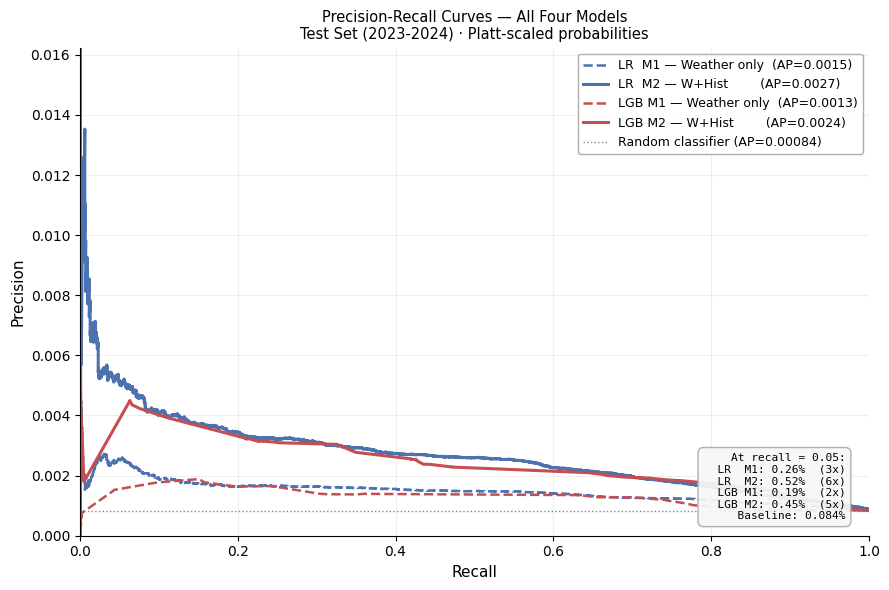

In [18]:
def precision_at_recall(p_arr, r_arr, tgt):
    mask = r_arr >= tgt
    return p_arr[mask].max() if mask.any() else np.nan

# Collect calibrated probabilities for all 4 models
cal_proba_lr1 = rc_lr['m1_te']['proba']
cal_proba_lr2 = rc_lr['m2_te']['proba']

p_lr1, r_lr1, _ = precision_recall_curve(y_test, cal_proba_lr1)
p_lr2, r_lr2, _ = precision_recall_curve(y_test, cal_proba_lr2)
p_l1,  r_l1,  _ = precision_recall_curve(y_test, cal_proba_lgb1)
p_l2,  r_l2,  _ = precision_recall_curve(y_test, cal_proba_lgb2)

baseline_ap = float(y_test.mean())
r05_cutoff  = 0.05

# y-axis cap at max precision with recall >= 0.005
y_ceil = max(p_lr1[r_lr1 >= 0.005].max(), p_lr2[r_lr2 >= 0.005].max(),
             p_l1[r_l1   >= 0.005].max(), p_l2[r_l2   >= 0.005].max()) * 1.2

annot_lines = ['At recall = 0.05:']
for lbl, p_a, r_a in [('LR  M1', p_lr1, r_lr1), ('LR  M2', p_lr2, r_lr2),
                       ('LGB M1', p_l1,  r_l1),  ('LGB M2', p_l2,  r_l2)]:
    v = precision_at_recall(p_a, r_a, r05_cutoff)
    annot_lines.append(f'  {lbl}: {v*100:.2f}%  ({v/baseline_ap:.0f}x)')
annot_lines.append(f'  Baseline: {baseline_ap*100:.3f}%')
annot_txt = '\n'.join(annot_lines)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(r_lr1, p_lr1, color='#4C72B0', lw=1.8, ls='--',
        label=f'LR  M1 — Weather only  (AP={rc_lr["m1_te"]["ap"]:.4f})')
ax.plot(r_lr2, p_lr2, color='#4C72B0', lw=2.2, ls='-',
        label=f'LR  M2 — W+Hist        (AP={rc_lr["m2_te"]["ap"]:.4f})')
ax.plot(r_l1,  p_l1,  color='#C44E52', lw=1.8, ls='--',
        label=f'LGB M1 — Weather only  (AP={rc_lgb["m1_te"]["ap"]:.4f})')
ax.plot(r_l2,  p_l2,  color='#C44E52', lw=2.2, ls='-',
        label=f'LGB M2 — W+Hist        (AP={rc_lgb["m2_te"]["ap"]:.4f})')
ax.axhline(baseline_ap, color='#888888', lw=1.0, ls=':',
           label=f'Random classifier (AP={baseline_ap:.5f})')

ax.text(0.97, 0.03, annot_txt, transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f7f7f7',
                  edgecolor='#aaaaaa', alpha=0.92))

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, y_ceil])
ax.set_title('Precision-Recall Curves — All Four Models\n'
             'Test Set (2023-2024) · Platt-scaled probabilities', fontsize=10.5)
ax.legend(fontsize=9, framealpha=0.95, edgecolor='#aaaaaa')
ax.grid(alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_PATH + 'lgb_pr_comparison_all_models.png', dpi=200, bbox_inches='tight')
plt.show()


#### 12. Nonlinear Interaction — Temperature × Fuel Type

Computing SHAP interaction values (2000 rows) ...
Interaction values shape: (2000, 18, 18)


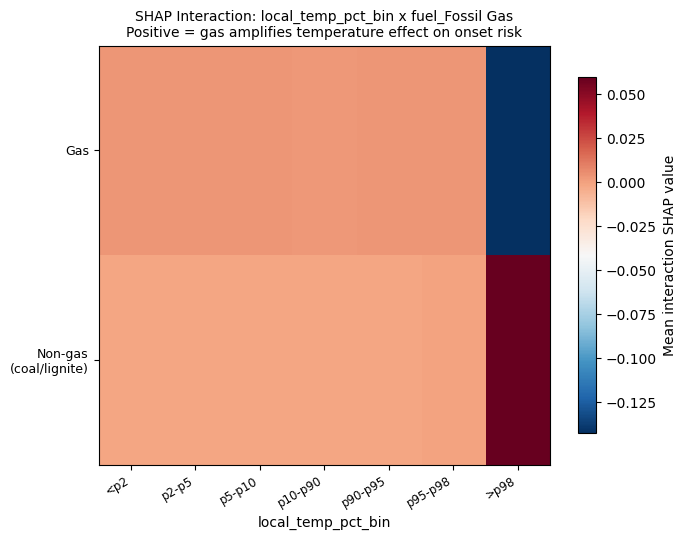

In [19]:
rng_int = np.random.default_rng(RANDOM_STATE)
inter_size = min(2000, len(shap_idx))
inter_sub  = rng_int.choice(len(shap_idx), size=inter_size, replace=False)
X_inter    = X_shap[inter_sub]
fuel_inter = fuel_label[inter_sub]

print(f'Computing SHAP interaction values ({inter_size} rows) ...')
shap_interact_raw = shap_explainer.shap_interaction_values(X_inter)
if isinstance(shap_interact_raw, list):
    shap_interact = shap_interact_raw[1]
else:
    shap_interact = shap_interact_raw
print(f'Interaction values shape: {shap_interact.shape}')

bin_i  = WEATHER_FEATURES.index('local_temp_pct_bin')
gas_i  = WEATHER_FEATURES.index('fuel_Fossil Gas')

# Mean interaction: temp_bin x fuel_gas (0/1) cells
bins_inter   = X_inter[:, bin_i].astype(int)
gas_inter    = (X_inter[:, gas_i] > 0.5).astype(int)
interact_mat = np.full((7, 2), np.nan)

for b in range(7):
    for g in [0, 1]:
        mask = (bins_inter == b) & (gas_inter == g)
        if mask.sum() > 0:
            interact_mat[b, g] = shap_interact[mask, bin_i, gas_i].mean()

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(interact_mat.T, aspect='auto', cmap='RdBu_r', origin='lower')
plt.colorbar(im, ax=ax, label='Mean interaction SHAP value', shrink=0.85)
ax.set_xticks(range(7))
ax.set_xticklabels(['<p2','p2-p5','p5-p10','p10-p90','p90-p95','p95-p98','>p98'],
                    fontsize=8.5, rotation=30, ha='right')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Non-gas\n(coal/lignite)', 'Gas'], fontsize=9)
ax.set_xlabel('local_temp_pct_bin', fontsize=10)
ax.set_title('SHAP Interaction: local_temp_pct_bin x fuel_Fossil Gas\n'
             'Positive = gas amplifies temperature effect on onset risk', fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_PATH + 'lgb_interaction_fuel_temp.png', dpi=200, bbox_inches='tight')
plt.show()


#### 13. Final Summary

In [22]:
print('4-MODEL FINAL COMPARISON')


lgb_m1_tr_auc = roc_auc_score(y_train, lgb_model1.predict_proba(X_tr_w)[:, 1])
lgb_m2_tr_auc = roc_auc_score(y_train, lgb_model2.predict_proba(X_tr_f)[:, 1])

print(f'{"":24} {"LR M1":>8} {"LR M2":>8} {"LGB M1":>8} {"LGB M2":>8}')
print(f'{"":24} {"(18f)":>8} {"(19f)":>8} {"(18f)":>8} {"(19f)":>8}')

print(f'{"Train AUC-ROC":<24} {lr_m1_tr_auc:>8.4f} {lr_m2_tr_auc:>8.4f} {lgb_m1_tr_auc:>8.4f} {lgb_m2_tr_auc:>8.4f}')
print(f'{"Val   AUC-ROC":<24} {rc_lr["m1_va"]["auc"]:>8.4f} {rc_lr["m2_va"]["auc"]:>8.4f} {r_lgb["m1_va"]["auc"]:>8.4f} {r_lgb["m2_va"]["auc"]:>8.4f}')
print(f'{"Test  AUC-ROC":<24} {rc_lr["m1_te"]["auc"]:>8.4f} {rc_lr["m2_te"]["auc"]:>8.4f} {rc_lgb["m1_te"]["auc"]:>8.4f} {rc_lgb["m2_te"]["auc"]:>8.4f}')
print(f'{"Test  AUC-PR":<24} {rc_lr["m1_te"]["ap"]:>8.4f} {rc_lr["m2_te"]["ap"]:>8.4f} {rc_lgb["m1_te"]["ap"]:>8.4f} {rc_lgb["m2_te"]["ap"]:>8.4f}')
print(f'{"Brier Score (test)":<24} {rc_lr["m1_te"]["brier"]:>8.4f} {rc_lr["m2_te"]["brier"]:>8.4f} {rc_lgb["m1_te"]["brier"]:>8.4f} {rc_lgb["m2_te"]["brier"]:>8.4f}')
print()
print(f'AUC gain: LGB vs LR (weather only):    {d_lgb_weather:+.4f}')
print(f'AUC gain: adding history (LGB):        {d_lgb_hist:+.4f}')
print(f'AUC gain: adding history (LR):         {d_lr_hist:+.4f}')
print()
top_feat     = lgb_importance.index[0]
bin_rank_lgb = (lgb_importance.index.tolist().index('local_temp_pct_bin') + 1)
print(f'Top feature by SHAP (LGB M1):          {top_feat}')
print(f'local_temp_pct_bin SHAP rank (LGB M1): {bin_rank_lgb}/18')
print(f'Spearman rank corr (LR vs LGB):        {rho:.3f}')

4-MODEL FINAL COMPARISON
                            LR M1    LR M2   LGB M1   LGB M2
                            (18f)    (19f)    (18f)    (19f)
Train AUC-ROC              0.6599   0.7684   0.6782   0.7833
Val   AUC-ROC              0.6728   0.7962   0.6378   0.7978
Test  AUC-ROC              0.6624   0.7603   0.6226   0.7572
Test  AUC-PR               0.0015   0.0027   0.0013   0.0024
Brier Score (test)         0.0008   0.0008   0.0008   0.0008

AUC gain: LGB vs LR (weather only):    -0.0398
AUC gain: adding history (LGB):        +0.1346
AUC gain: adding history (LR):         +0.0979

Top feature by SHAP (LGB M1):          capacity_size
local_temp_pct_bin SHAP rank (LGB M1): 8/18
Spearman rank corr (LR vs LGB):        0.671


In [ ]:
# Save predictions for robustness_checks.ipynb
import numpy as np
PRED_DIR = '../data/predictions/'
import os; os.makedirs(PRED_DIR, exist_ok=True)

np.save(PRED_DIR + 'y_test.npy',         y_test)
np.save(PRED_DIR + 'cal_proba_lr1.npy',  cal_proba_lr1)
np.save(PRED_DIR + 'cal_proba_lr2.npy',  cal_proba_lr2)
np.save(PRED_DIR + 'cal_proba_lgb1.npy', cal_proba_lgb1)
np.save(PRED_DIR + 'cal_proba_lgb2.npy', cal_proba_lgb2)

test[['DateTime', 'fuel_Fossil Gas', 'fuel_Fossil Brown coal/Lignite']]\n    .to_parquet(PRED_DIR + 'df_test.parquet', index=False)

print('Saved to', PRED_DIR)
